Train a segmentation model using the HAM 10000 kaggle dataset

Using the kaggle API - Need to create a token and store it at 

C:\Users\<Windows-username>\.kaggle\kaggle.json on Windows

Environment variable with KAGGLEHUB_CACHE is also required

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import pandas as pd

import torch
from torch.utils.data import Dataset
from torchvision.io import read_image

from dotenv import load_dotenv
load_dotenv()

import matplotlib.pyplot as plt

c:\Users\colwy\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
HAM10K_file_path = "HAM10000_metadata.csv"

print(os.getenv("KAGGLEHUB_CACHE"))
os.environ["KAGGLEHUB_CACHE"] = os.getenv("KAGGLEHUB_CACHE")

#Kaggle datasets
HAM10K_datset_kaggle_url = "kmader/skin-cancer-mnist-ham10000"

#Download the image files
HAM10K_dataset_path = kagglehub.dataset_download(HAM10K_datset_kaggle_url, force_download=False)

HAM10K_dataset_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    HAM10K_datset_kaggle_url,
    HAM10K_file_path
)

print("\nFirst 5 items of dataset")
print(HAM10K_dataset_df.head())

print("\nColumn datatypes")
print(HAM10K_dataset_df.dtypes)

print(HAM10K_dataset_df.describe())

C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\src\skin_lesion_segmentation\kaggle
C:\Users\colwy\Documents\SFU\Spring2025\CMPT 419\Project\2025_1_project_06\src\skin_lesion_segmentation\kaggle\datasets\kmader\skin-cancer-mnist-ham10000\versions\2

First 5 items of dataset
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Column datatypes
lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object
               age
count  9958.000000
mean     51.863828
std      16.968614
min       0.000000
2

Clean the dataset by removing null values

In [14]:
print(HAM10K_dataset_df.isnull().sum())

#Replace null values with the mean
HAM10K_dataset_df['age'].fillna(int(HAM10K_dataset_df['age'].mean()),inplace=True)

print("\n\n",HAM10K_dataset_df.isnull().sum())


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


 lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64


Sort by ISIC image ID to match the ordering of the segmentation masks

In [5]:
sorted_HAM_dataset = HAM10K_dataset_df.sort_values(
    by="image_id", 
    key=lambda id: id.str.lstrip("ISIC_").astype(int)
)

Create a mapping of the HAM 10000 dx column to Lesion Type

In [6]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

Load the segmentation masks

In [ ]:
HAM10K_segmentations_file_path = os.path.join(os.getcwd(), "HAM10K_segmentations")
cache_dir = os.path.join(os.getcwd(), "kagglehub_cache")

HAM10K_segmentations_kaggle_url = "tschandl/ham10000-lesion-segmentations"

# Load the segmentation data from tschandl's dataset
HAM10K_segmentations_dataset_path = kagglehub.dataset_download("tschandl/ham10000-lesion-segmentations", force_download=False)

'C:\\Users\\colwy\\Documents\\SFU\\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\skin_lesion_segmentation\\kaggle\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1'

In [ ]:
def getSkinLesionImageFromIndex(index):
    

class LesionDataset(Dataset):
    def __init__(self, annotations, img_dir, mask_dir, transform=None, mask_transform=None):
        super().__init__()
        self.img_labels = annotations
        # self.image_names = os.listdir(img_dir)
        self.mask_dir = mask_dir
        self.mask_names = os.listdir(mask_dir)
        self.transform = transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.mask_names)

    def __getitem__(self, index):
        label = self.img_labels.iloc[index]
        mask_path = os.path.join(self.mask_dir, self.mask_names[index])
        
        mask = read_image(mask_path)
        return label, mask

lesion_id        HAM_0000550
image_id        ISIC_0024306
dx                        nv
dx_type            follow_up
age                     45.0
sex                     male
localization           trunk
Name: 4349, dtype: object


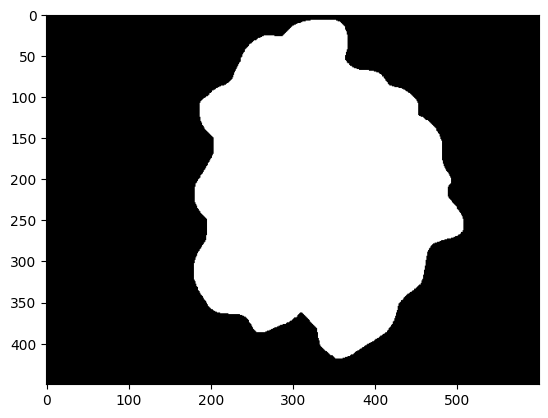

In [9]:
dataset_path = os.getenv("KAGGLEHUB_CACHE")

lesion_dataset = LesionDataset(sorted_HAM_dataset, "", dataset_path + "\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1\\HAM10000_segmentations_lesion_tschandl")

label, mask = lesion_dataset.__getitem__(0)  # Use the correct indexing method
print(label)
plt.imshow(mask.squeeze(), cmap="gray")  # Use .squeeze() if the mask has an extra dimension
plt.show()

In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use GPU
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")  # Fallback to CPU
    print("CUDA not available, using CPU.")

Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU
